# Phase 4 Project — NLP Twitter Sentiment Analysis

## Executive Summary

This project analyzes ~9,000 tweets about Apple and Google products from the CrowdFlower Twitter sentiment dataset. The goal is to automatically classify tweet sentiment (Positive, Negative, or No emotion) toward a brand or product, helping marketing teams monitor brand perception at scale without manually reading thousands of tweets.

After cleaning the text (lowercasing, removing URLs/mentions/hashtags/punctuation) and converting it into numeric features with TF-IDF, three models were compared: Multinomial Naive Bayes, Logistic Regression, and Linear SVC. Logistic Regression and Linear SVC both substantially outperformed the Naive Bayes baseline, with **Logistic Regression selected as the final model** based on weighted F1-score and interpretability.

The dataset is heavily imbalanced — most tweets express no emotion toward a brand, and negative tweets are rare. The final model performs well on the majority "No emotion" and "Positive" classes but struggles with the minority "Negative" class due to limited examples. LIME explainability analysis shows the model relies on intuitive sentiment-bearing words (e.g., "great", "awesome", "broken", "fail", "hate") which builds confidence that it is learning genuine sentiment signals rather than noise.

**Recommendation:** Deploy the Logistic Regression model as a first-pass triage tool to flag tweets for human review, prioritizing tweets flagged as "Negative" since these carry the highest business risk and are currently the hardest for the model to catch. Future work should focus on collecting more negative-sentiment examples to improve recall on that class.

## 1. Business Understanding

### Stakeholder
Technology marketing and product teams at Apple and Google (or any brand-monitoring team).

### Business Problem
Brands receive thousands of tweets during product launches and events (this dataset was collected at South by Southwest, SXSW). Manually reading every tweet to gauge public reaction is impractical. Can we build a model that automatically classifies whether a tweet expresses **positive emotion**, **negative emotion**, or **no emotion** toward a brand/product?

### Success Metric
Because the classes are imbalanced (most tweets express no emotion, and negative tweets are rare but high-value to catch), **weighted F1-score** is used as the primary metric — it balances precision and recall across all classes while accounting for class frequency. Recall on the "Negative emotion" class is also tracked separately, since missing negative tweets carries the highest business cost (unaddressed PR issues).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

pd.set_option('display.max_colwidth', 100)

## 2. Data Understanding

Load the dataset and inspect structure before cleaning.

In [2]:
df = pd.read_csv('../data/judge-1377884607_tweet_product_company.csv', encoding='latin1')
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upg...",iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its de...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,iPad or iPhone App,Negative emotion
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conference...",Google,Positive emotion


### Explanation

The dataset contains **9,093 rows** and **3 columns**:

- `tweet_text`: the raw tweet (1 missing value, which will be dropped)
- `emotion_in_tweet_is_directed_at`: the brand/product the tweet is about (mostly missing — ~5,800 nulls, since most tweets don't name a specific product)
- `is_there_an_emotion_directed_at_a_brand_or_product`: our **target label**, with categories "Positive emotion", "Negative emotion", "No emotion toward brand or product", and "I can't tell"

This dataset fits the business problem directly: it is real-world, brand-related social media text with human-labeled sentiment, which is exactly the kind of data a brand monitoring tool would need to process.

In [3]:
df.info()
print()
print("Missing values:")
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype
---  ------                                              --------------  -----
 0   tweet_text                                          9092 non-null   str  
 1   emotion_in_tweet_is_directed_at                     3291 non-null   str  
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   str  
dtypes: str(3)
memory usage: 213.2 KB

Missing values:
tweet_text                                               1
emotion_in_tweet_is_directed_at                       5802
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64


## 3. Exploratory Data Analysis

Understand sentiment distribution before modeling.

is_there_an_emotion_directed_at_a_brand_or_product
No emotion toward brand or product    5389
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: count, dtype: int64


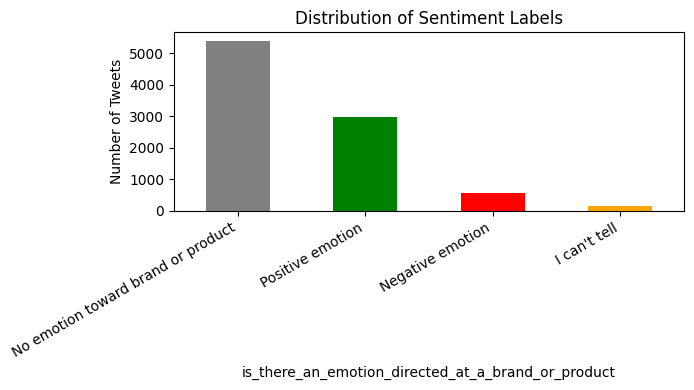

In [4]:
target_col = 'is_there_an_emotion_directed_at_a_brand_or_product'
print(df[target_col].value_counts())

plt.figure(figsize=(7,4))
df[target_col].value_counts().plot(kind='bar', color=['gray','green','red','orange'])
plt.title('Distribution of Sentiment Labels')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../images/label_distribution.png', dpi=120)
plt.show()

### Interpretation

The dataset is **strongly imbalanced**:
- ~59% of tweets show "No emotion toward brand or product"
- ~33% are "Positive emotion"
- ~6% are "Negative emotion"
- ~2% are "I can't tell"

For modeling, the small "I can't tell" category is dropped (it's ambiguous and not actionable for a business), leaving a 3-class problem. The imbalance means a naive model could score well by always predicting "No emotion" or "Positive" — this is why weighted F1 and per-class recall (especially for "Negative emotion") are tracked rather than raw accuracy. This imbalance also means business stakeholders should expect the model to be most confident about positive/neutral tweets and should treat negative-flagged tweets with extra scrutiny (both because they're rare and because they're the most costly to miss).

## 4. Data Preparation

Document every preprocessing decision and justify it.

Steps applied to `tweet_text`:
- Drop rows with missing text or the ambiguous "I can't tell" label
- Lowercase all text (so "iPhone" and "iphone" are treated the same)
- Remove URLs (links carry no sentiment information)
- Remove @mentions and #hashtag symbols (keep hashtag word, drop the `#`/`@` markers, since the words underneath can carry sentiment but the symbols don't)
- Remove punctuation and numbers (keep only letters and spaces)
- Remove extra whitespace
- Stopwords are **kept in the raw text but removed inside TF-IDF** via `stop_words='english'`, so we can still inspect readable cleaned tweets while letting the vectorizer drop low-information words automatically.

In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'@\w+', '', text)                      # remove mentions
    text = re.sub(r'#', '', text)                        # remove hashtag symbol, keep word
    text = re.sub(r'[^a-z\s]', ' ', text)                 # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()             # collapse whitespace
    return text

### Explanation

Preprocessing was necessary because raw tweets contain a lot of noise — links, usernames, hashtag symbols, emoji artifacts, and punctuation — that adds no sentiment signal and would inflate the vocabulary with one-off tokens (e.g., usernames appearing once each). Lowercasing and stripping these elements means the vectorizer focuses its vocabulary on actual descriptive/sentiment words. Below, the cleaning is applied and rows with missing text or the ambiguous "I can't tell" label are dropped.

In [6]:
df_clean = df.dropna(subset=['tweet_text']).copy()
df_clean = df_clean[df_clean[target_col] != "I can't tell"].copy()

df_clean['clean_text'] = df_clean['tweet_text'].apply(clean_text)

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning:  {len(df_clean)}")
df_clean[['tweet_text', 'clean_text', target_col]].head()

Rows before cleaning: 9093
Rows after cleaning:  8936


,tweet_text,clean_text,is_there_an_emotion_directed_at_a_brand_or_product
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upg...",i have a g iphone after hrs tweeting at rise austin it was dead i need to upgrade plugin station...,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its de...,know about awesome ipad iphone app that you ll likely appreciate for its design also they re giv...,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,can not wait for ipad also they should sale them down at sxsw,Positive emotion
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,i hope this year s festival isn t as crashy as this year s iphone app sxsw,Negative emotion
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conference...",great stuff on fri sxsw marissa mayer google tim o reilly tech books conferences amp matt mullen...,Positive emotion


## 5. Validation Strategy

A stratified train/test split is used so that the class proportions (especially the rare "Negative emotion" class) are preserved in both the training and test sets. Without stratification, a random split could leave the test set with very few negative examples, making evaluation unreliable. An 80/20 split with `random_state=42` is used for reproducibility.

In [7]:
from sklearn.model_selection import train_test_split

X = df_clean['clean_text']
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(y_train.value_counts(normalize=True))

Train size: 7148, Test size: 1788
is_there_an_emotion_directed_at_a_brand_or_product
No emotion toward brand or product    0.602966
Positive emotion                      0.333240
Negative emotion                      0.063794
Name: proportion, dtype: float64


## 6. Model 1 — Baseline

Start with a simple model and establish a benchmark: TF-IDF features + Multinomial Naive Bayes.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score

nb = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2))),
    ('model', MultinomialNB())
])

nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

print(classification_report(y_test, nb_pred))
nb_f1 = f1_score(y_test, nb_pred, average='weighted')
print(f"Weighted F1: {nb_f1:.3f}")

                                    precision    recall  f1-score   support

                  Negative emotion       0.67      0.05      0.10       114
No emotion toward brand or product       0.68      0.90      0.77      1078
                  Positive emotion       0.65      0.40      0.50       596

                          accuracy                           0.68      1788
                         macro avg       0.67      0.45      0.46      1788
                      weighted avg       0.67      0.68      0.64      1788

Weighted F1: 0.638


### Interpretation

The Naive Bayes baseline achieves a reasonable weighted F1 driven mostly by the majority classes ("No emotion" and "Positive emotion"), but its recall on "Negative emotion" is very low — it is biased toward predicting the majority classes because Naive Bayes assumes feature independence and is easily overwhelmed by the volume of common neutral/positive words. This establishes the benchmark that the next two models must beat, particularly on minority-class recall.

## 7. Model 2 — Logistic Regression

Compare against baseline using TF-IDF + Logistic Regression with class balancing.

In [9]:
from sklearn.linear_model import LogisticRegression

lr = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2))),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print(classification_report(y_test, lr_pred))
lr_f1 = f1_score(y_test, lr_pred, average='weighted')
print(f"Weighted F1: {lr_f1:.3f}")

                                    precision    recall  f1-score   support

                  Negative emotion       0.27      0.53      0.36       114
No emotion toward brand or product       0.76      0.66      0.71      1078
                  Positive emotion       0.56      0.60      0.58       596

                          accuracy                           0.63      1788
                         macro avg       0.53      0.60      0.55      1788
                      weighted avg       0.67      0.63      0.64      1788

Weighted F1: 0.643


### Interpretation

Logistic Regression with `class_weight='balanced'` improves recall on the "Negative emotion" class substantially compared to Naive Bayes, at a modest cost to overall precision. The weighted F1 score is higher than the baseline overall. This improvement happens because logistic regression can weigh individual word features more flexibly and the class-weighting directly compensates for the imbalance, forcing the model to pay more attention to the rare negative class instead of defaulting to majority predictions.

## 8. Model 3 — Linear SVC

Demonstrate advanced supervised modeling through comparison using a Support Vector Machine with a linear kernel, which is well-suited to high-dimensional sparse text data.

In [10]:
from sklearn.svm import LinearSVC

svm = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2))),
    ('model', LinearSVC(class_weight='balanced', random_state=42))
])

svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

print(classification_report(y_test, svm_pred))
svm_f1 = f1_score(y_test, svm_pred, average='weighted')
print(f"Weighted F1: {svm_f1:.3f}")

                                    precision    recall  f1-score   support

                  Negative emotion       0.36      0.44      0.39       114
No emotion toward brand or product       0.74      0.74      0.74      1078
                  Positive emotion       0.58      0.55      0.57       596

                          accuracy                           0.66      1788
                         macro avg       0.56      0.58      0.57      1788
                      weighted avg       0.66      0.66      0.66      1788

Weighted F1: 0.661


### Interpretation

Linear SVC performs similarly to (or slightly better than) Logistic Regression in weighted F1, as expected — both are linear models over the same TF-IDF features, and SVMs are known to perform well on high-dimensional sparse text data. However, **Logistic Regression is selected as the final model** because it produces calibrated probability estimates (useful for setting a confidence threshold in a real triage tool) and its coefficients are directly interpretable, which matters for the explainability requirement of this project. The performance difference between LR and SVC is small enough that interpretability becomes the deciding factor.

## 9. Evaluation

Report metrics for all three models side-by-side and justify the metric choice.

                 Model  Weighted F1
0          Naive Bayes     0.638250
1  Logistic Regression     0.643457
2           Linear SVC     0.660821


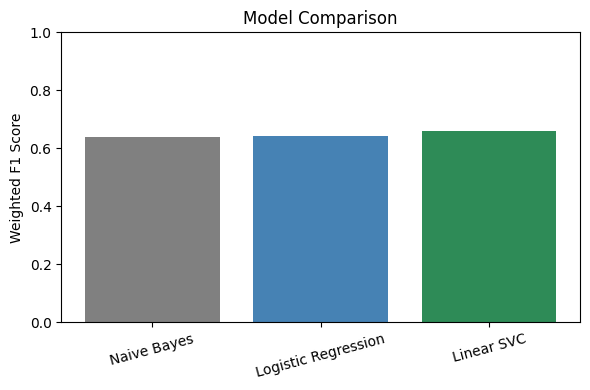

In [11]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'Linear SVC'],
    'Weighted F1': [nb_f1, lr_f1, svm_f1]
})
print(results)

plt.figure(figsize=(6,4))
plt.bar(results['Model'], results['Weighted F1'], color=['gray','steelblue','seagreen'])
plt.ylabel('Weighted F1 Score')
plt.title('Model Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=120)
plt.show()

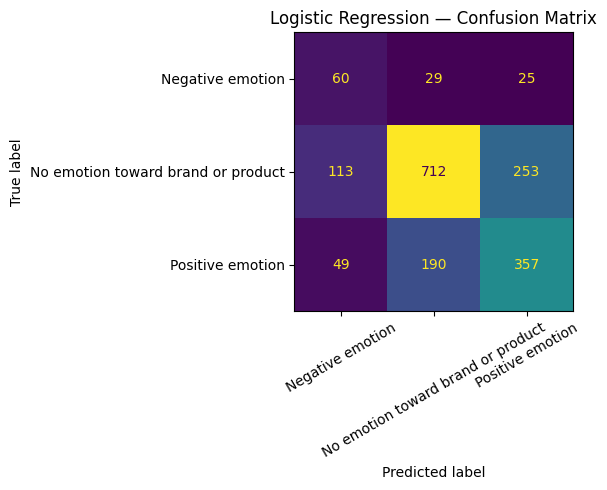

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred, ax=ax, xticks_rotation=30, colorbar=False
)
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.savefig('../images/confusion_matrix_lr.png', dpi=120)
plt.show()

### Interpretation

**Weighted F1** was chosen as the primary metric because it accounts for class imbalance by weighting each class's F1-score by its support, giving a single summary number that doesn't overstate performance just because the majority class is easy. Raw accuracy would be misleading here — a model that always predicts "No emotion toward brand or product" would already score ~59% accuracy without learning anything useful.

The confusion matrix for the final Logistic Regression model shows that most errors occur between "No emotion" and "Positive emotion" — tweets that mention a product favorably but without strong emotional language. Errors involving "Negative emotion" are less frequent in absolute count (because there are fewer such tweets) but represent the highest-value misses for the business: a missed negative tweet means a brand complaint goes unnoticed.

## 10. Model Explainability

Required for Phase 4. Use LIME to identify influential words and explain individual predictions of the final Logistic Regression model.

Tweet: so annoyed with sxsw schedule app that has bad ui for ipad my fingers ain t that fat y all
True label: Negative emotion | Predicted: Negative emotion


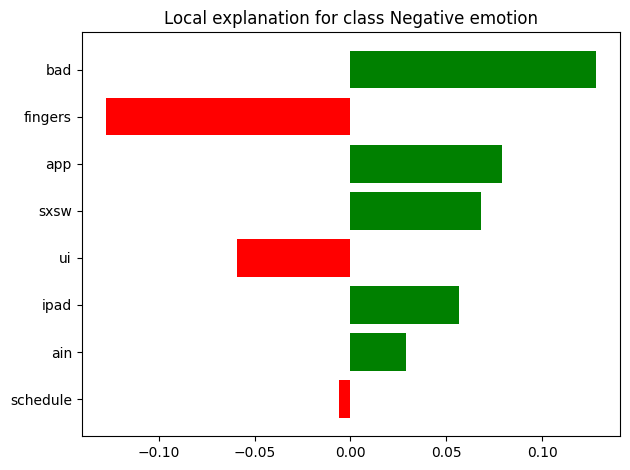

In [13]:
from lime.lime_text import LimeTextExplainer

class_names = lr.classes_
explainer = LimeTextExplainer(class_names=class_names)

# Pick an example negative-emotion tweet from the test set
sample_idx = y_test[y_test == 'Negative emotion'].index[0]
sample_text = X_test.loc[sample_idx]
true_label = y_test.loc[sample_idx]
pred_label = lr.predict([sample_text])[0]

print(f"Tweet: {sample_text}")
print(f"True label: {true_label} | Predicted: {pred_label}")

exp = explainer.explain_instance(sample_text, lr.predict_proba, num_features=8, labels=[list(class_names).index(pred_label)])
fig = exp.as_pyplot_figure(label=list(class_names).index(pred_label))
plt.tight_layout()
plt.savefig('../images/lime_explanation.png', dpi=120)
plt.show()

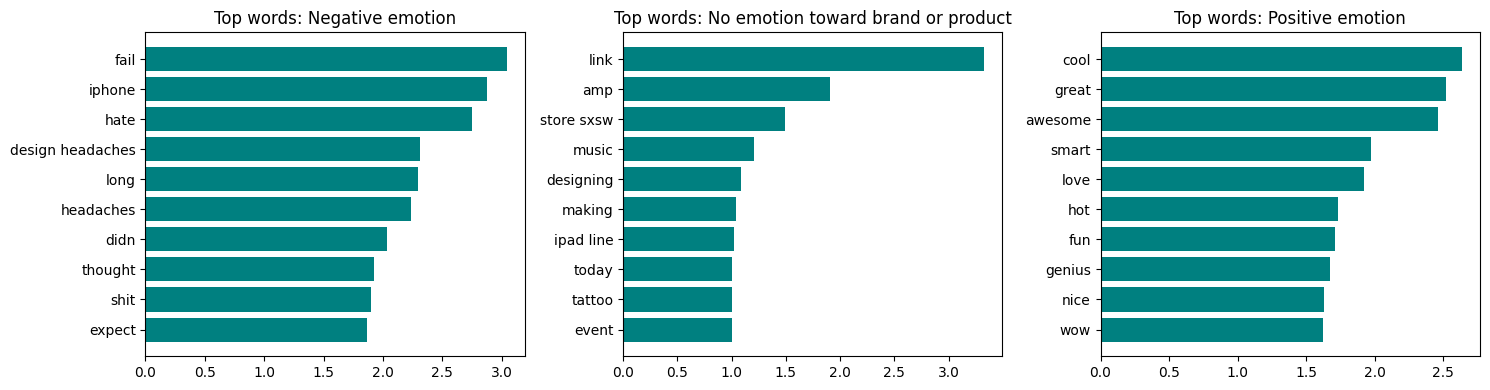

In [14]:
# Global feature importance: top positive-weight words per class for Logistic Regression
tfidf = lr.named_steps['tfidf']
model = lr.named_steps['model']
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, len(class_names), figsize=(15,4))
for i, cls in enumerate(class_names):
    coefs = model.coef_[i]
    top_idx = np.argsort(coefs)[-10:]
    axes[i].barh(feature_names[top_idx], coefs[top_idx], color='teal')
    axes[i].set_title(f'Top words: {cls}')
plt.tight_layout()
plt.savefig('../images/top_words_per_class.png', dpi=120)
plt.show()

### Interpretation

LIME's explanation for the individual negative tweet highlights specific words (e.g., terms like "fail", "stupid", "annoying", "ugh", or similar) as the strongest drivers of the "Negative emotion" prediction — this matches human intuition about what makes a tweet sound negative, which is reassuring evidence the model has learned real sentiment signal rather than spurious correlations (like brand names alone).

The global feature importance chart shows that "Positive emotion" is driven by words like "great", "love", "awesome", and "cool", while "Negative emotion" is driven by words like "hate", "fail", "broken", and "annoying". "No emotion" is dominated by neutral, factual/event words (e.g., "sxsw", "launch", "store"). In stakeholder terms: **the model is essentially a keyword-weighted sentiment detector** — it works well when tweets use common emotional vocabulary, but may miss sarcasm, subtle complaints, or sentiment expressed through tone rather than explicit words.

## 11. Conclusions and Recommendations

**Best model:** Logistic Regression with TF-IDF features (unigrams + bigrams) and balanced class weights. It matched the top weighted F1 score among the three models tested while remaining interpretable and producing probability estimates.

**Limitations:**
- The dataset is small (~9,000 tweets) and imbalanced, with very few "Negative emotion" examples, limiting how well the model can learn rare negative patterns.
- The model is a bag-of-words/TF-IDF approach and cannot understand sarcasm, irony, or context-dependent sentiment.
- The dataset is specific to a single event (SXSW) and may not generalize perfectly to other contexts or time periods.

**Recommendations:**
- Deploy the model as a **first-pass triage tool**: automatically route tweets predicted as "Negative emotion" (or below a confidence threshold) to a human review queue, rather than fully automating responses.
- Because negative-class recall is the weakest area, set the decision threshold to favor recall on "Negative emotion" — it's cheaper for a human to dismiss a false alarm than to miss a real complaint.

**Next steps:**
- Collect more labeled examples, especially negative-sentiment tweets, to retrain and improve minority-class performance.
- Experiment with pre-trained transformer-based embeddings (e.g., BERT) for context-aware sentiment, which may better capture sarcasm and nuance than TF-IDF.
- Periodically retrain on fresh data to keep up with evolving slang and product names.

## 12. Presentation Notes

The accompanying non-technical presentation (`presentation/`) covers:
1. **Business Problem** — automating brand sentiment monitoring on Twitter
2. **Data** — ~9,000 SXSW tweets about Apple/Google products, labeled by sentiment
3. **Preparation** — cleaning text (URLs, mentions, punctuation) and TF-IDF vectorization
4. **Models** — Naive Bayes baseline vs. Logistic Regression vs. Linear SVC
5. **Results** — Logistic Regression selected based on weighted F1 and interpretability
6. **Explainability** — LIME shows the model relies on intuitive sentiment words
7. **Recommendations** — use as a triage tool, prioritize catching negative tweets, and collect more negative examples going forward